# AV1 Computação Gráfica (Igor Roberto Alves, Lucas Barros, Barcelos)

## Alguns anúncios prévios:

- Não é preciso rodar esse notebook, Todas as células são de caráter educativo e buscam explorar cada detalhe desse repositório, porém, sem por integramente na prática.

- Caso queira rodar, basta chamar as seguintes linhas de comando antes de dar `play` no notebook:

In [ ]:
# Caso queira rodar retire as aspas

"""

!pip install -r requirements.txt

"""

- As imagens apresentadas serão carregadas por meio de arquivos "png", porém a verificabilidade da geração fica disponível pela transparência de todos os códigos geradores.

- O código é inteiramente composto por python, e na maioria das operações utilizamos pytorch para acessar o caráter paralelizável do algorítmo

## Ray-Tracing

### Definições Iniciais

Quando pensamos em implementar o Ray-Tracing, não podemos nos esquecer dos elementos básicos que permeiam integralmente o algorítmo, por isso começemos falando sobre:

#### Definição de câmera

A definição de câmera pode ser encontrada em ./Base/Cam.py :

<img>
<img src = "Explain_Imgs/Cam_Init.png", width = "1000", height = "500">
</img>

A definição de parâmetros aqui é basica

- device: Por definição mantemos cpu, porém quando formos renderizar poderemos escolher qual device iremos usar (A diferença entre "cpu" e "cuda" será explorada no decorrer do notebook);

- img_width e img_height definem a janela da imagem resultante;

- eye: É o ponto em que a câmera está localizada;

- look_at: Para onde a câmera aponta;

- up: define aonde é em cima da câmera

- fov: define o campo de visão da câmera

Os outros atributos são todos derivados desses básicos e farão sentido ao decorrer do código

A classe Camera possui uma única e importantíssima função: **generate_all_rays**


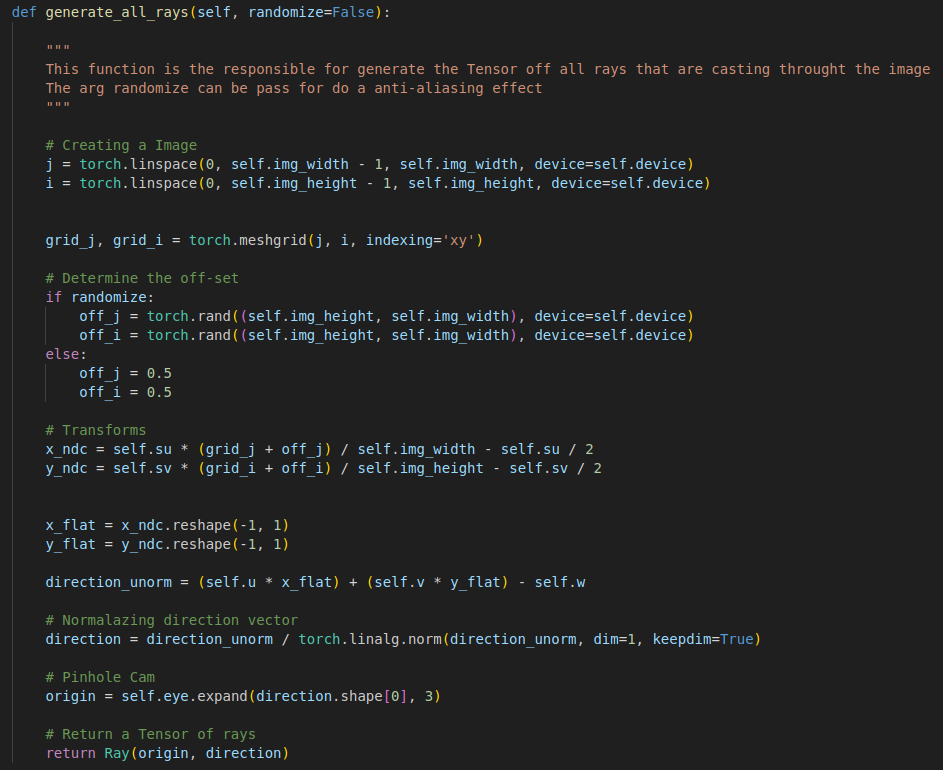

Essa função é responsável por gerar todos os dados primários da imagem de forma vetorizada. Inicialmente gera as coordenadas de cada pixel da imagem utilizando tensores do PyTorch. Além disso, ela tem um parametro 'randomize' que serve para fazer anti alising caso seja ativado aplicando um leve deslocamento aleatório em cada pixel para diminuir o serrilhado da imagem. Depois de gerar ela faz uma transformação para o espaço 3D calcula os vetores de direção nomrlaizados e define a origem em 'eye'. No fim retorna um objeto 'Ray' contendo as informações dos raios.

### Ray, Obj e HitRecord

Esses objetos se encontram em Primitives/base.py e agora vamos destrinchar um pouco cada um:

<img>
<img src = "Explain_Imgs/base_explain.png", width  = "1000", height = "500">
</img>

**Ray** aqui para nós não carregará apenas um raio, e sim significará um tensor com $N$ raios $\in \mathbb{R}^3$, ou seja, um tensor (N, 3) de origens e um tensor (N, 3) de direções

A única função que **Ray** precisa carregar é "point_at" que recebe um tensor K (N, 1) de reais e apenas retorna a posição de todos os raios movidos K em suas devida direções

Já **Obj** é uma classe mãe que será herdada por qualquer tipo de objeto gráfico, em geral é só uma formalidade, já que ela apenas indica a presença de um nome (que pode também não ser passado), e setta hit como não implementado

Por fim, **HitRecord** é um dos corações do algorítmo.

Com essa classe, queremos criar um objeto que funcione como um arquivo do que que aconteceu com o tensor de raios em um certo objeto, para isso, HitRecord guarda:

- hit_mask: vale 1 para raios que encontraram o objeto e 0 para raios que não encontraram

- t: após andar quanto na direção que tal raio encontrou o objeto? Isso que t carrega.

- point: Em coordenadas da cena, aonde foi que os raios bateram no objeto?

- normal: Qual era a normal relativa do objeto neste ponto?

- materials: Do que era feito aquela parte do objeto (Essencial para o cálculo de cores, veremos à frente)

#### Lights e Material

**PointLight**

<img>
<img src = "Explain_Imgs/Cam_Init.png", width = "1000", height = "500">
</img>

PointLIght é uma classe que recebe a classe Light, ou seja, ela é um dos tipos de luzes da implementação. Ela é o mais simples de todos sendo apenas um ponto que emite luz igualmente em todas as direções. Ela armazena informações de posição, cor e intensidade como tensores do PyTorch, facilitando os cálculos de sombreamento e direção de luz de forma eficiente durante o processo de renderização.

**SimpleMaterial**

<img>
<img src = "Explain_Imgs/Cam_Init.png", width = "1000", height = "500">
</img>

A classe SimpleMaterial define as propriedades ópticas das superfícies e implementa o modelo de iluminação de Phong. Através do método shade, ela calcula a cor final de cada ponto de interseção considerando três componentes: a iluminação ambiente, a difusa (que depende do ângulo com a fonte de luz) e a especular (que gera o brilho de reflexo baseado na posição da câmera). Além disso, a classe gerencia o cálculo de sombras projetadas ao disparar raios secundários em direção às luzes da cena para verificar obstruções, garantindo que apenas áreas visíveis recebam contribuição direta das fontes de luz. Todo o cálculo é realizado de forma vetorial com PyTorch, permitindo o processamento eficiente de múltiplos materiais e luzes simultaneamente.

### Problemas de Interseção

#### Plane, Triangle e Ball

##### Plane

A classe Plane implementa a geometria de um plano infinito no espaço 3D, definido por um ponto de origem e um vetor normal. No método hit, a classe calcula a interseção entre o plano e um conjunto de raios de forma puramente algébrica, resolvendo a equação para encontrar o ponto onde o raio atravessa a superfície. Nessa implementação tratamos de casos de raios paralelos ao plano para evitar divisões por 0 e também usa uma máscara para apenas conntabilizar interseções com t maior que 0.001, ou seja na frente da camera, essa função como as outras é totalmente vetorizada em Pytorch para usarmos a GPU e acelerar o render.

##### Triangle

A classe Triangle implementa a primitiva geométrica de triângulo, utilizando coordenadas baricêntricas (Algorítmo de Moller-Trumbore) para validar as interseções. O método hit primeiro calcula o ponto de encontro entre o raio e o plano definido pelo triângulo e, em seguida, verifica se esse ponto está dentro dos limites dos três vértices. Essa implementação também da suporte à interpolação de normais permitindo que a classe calcule uma normal mais suave para o ponto baseado nos pesos baricentricos faznedo com que objetos de malha traingular por exemplo sejam renderizados de forma mais suave e perdendo um pouco do aspecto de "dureza" comunmente passado com malhas de poucos triangulos o que nos retorna uma imagem com maior qualidade exigindo menos poder computacional. Assim com oo resto do código é otimizado para lógica de tensores.

## Como criar uma cena?

Após definirmos o básico que uma cena contém (Câmera, Raios, Objetos, Materiais, ...) nos perguntamos agora, como podemos de fato construir uma cena? É isso que o arquivo **BaseScene.py** nos mostra.

Mas, antes de tudo, como estamos tratando apenas de malhas triangulares e planos na nossa implementação, temos que passar para nossa cena quais são os triângulos pertencentes e os respectivos planos que queremos.

Para isso buscamos apoio em **ObjTotri.py** 

<img>
<img src = "Explain_Imgs/Cam_Init.png", width = "1000", height = "500">
</img>

Aqui queremos passar um arquivo ".obj" e retornarmos com uma sopa de triângulos que poderá ser passada para nossa cena, também aproveitamos a coleta dos vértices para calcular as suas normais que serão imprescindíveis no processo de calcular a normal do ponto de interção do raio com o triângulo.

Voltando para **BaseScene.py**, vamos analisar o que uma cena deve conter para sua inicialização:

<img>
<img src = "Explain_Imgs/Sceneinit.png", width = "1000", height = "500">
</img>

Toda cena deve conter:

O backgroud definido como a cor retornada quando o raio não atinge nenhum objeto,

uma cor ambiente que será considerada para o shadding assim como no modelo de iluminação de Phong

A câmera que capturará a cena

Todas as luzes que permeiam a cena

E por fim, os objetos e seus respectivos materiais

Na classe Scene, já recebemos a função hit implementada, já que para qualquer cena, o cálculo de interseções será feito da mesma maneira

### Definindo o hit da cena

<img>
<img src = "Explain_Imgs/SceneHit.png", width = 1000, height = 500>
<\img>

Exemplos concretos

## Render em Chunks

Como é colorido?

loop principal

Anti-Aliasing e Area Light